# Executive Hotel Booking — Exploratory Data Analysis (EDA)
### Day 15 Assignment | Data Science Workflow

**Objective:** Understand booking behaviour, cancellations, revenue drivers and guest satisfaction across a portfolio of hotels, and translate findings into management recommendations.

**Dataset:** `Day15_Executive_Hotel_Booking_EDA_Dataset.csv` — 25,180 hotel bookings across 10 cities, 35 attributes (booking details, guest profile, revenue, satisfaction, cancellation status).

**Workflow:**
1. Data Understanding
2. Data Quality Assessment
3. Data Cleaning & Preprocessing
4. Descriptive Statistics
5. Univariate Analysis
6. Bivariate & Group-wise Analysis
7. Correlation Analysis
8. Key Business Insights
9. Management Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100

CHART_DIR = 'charts'
import os
os.makedirs(CHART_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f'{CHART_DIR}/{name}.png', dpi=140, bbox_inches='tight')


## 1. Data Understanding

In [2]:
df = pd.read_csv('Day15_Executive_Hotel_Booking_EDA_Dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (25180, 35)


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,0,ARE,Direct,Direct,1,0,6,H,H,0,Non Refund,103.0,NaN,5,Contract,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,0,JPN,Groups,Direct,0,0,0,H,H,0,No Deposit,80.0,NaN,3,Contract,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,0,POL,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,53.0,NaN,2,Transient,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,0,CAN,Offline TA/TO,TA/TO,0,0,0,H,H,3,No Deposit,96.0,NaN,0,Contract,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,0,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,51.0,NaN,3,Group,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  str    
 1   Hotel_Type                   25180 non-null  str    
 2   Hotel_Location               25074 non-null  str    
 3   Booking_Date                 25180 non-null  str    
 4   Arrival_Date                 25180 non-null  str    
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  str    
 12  Market_Segment               25180 non-null  str    
 13  Distribution_Channel       

In [4]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Lead_Time_Days,25180.0,182.200556,105.604452,0.00,91.00,182.000,273.0000,920.00
Weekend_Nights,25180.0,1.240429,1.063802,0.00,0.00,1.000,2.0000,3.00
Weekday_Nights,25180.0,2.451072,2.031003,0.00,1.00,2.000,4.0000,13.00
Adults,25180.0,2.198967,0.662379,1.00,2.00,2.000,2.0000,7.00
Children,25059.0,0.372122,0.657811,0.00,0.00,0.000,1.0000,6.00
Babies,25180.0,0.043050,0.225057,0.00,0.00,0.000,0.0000,2.00
Is_Repeated_Guest,25180.0,0.172597,0.377906,0.00,0.00,0.000,0.0000,1.00
Previous_Cancellations,25180.0,0.038642,0.251403,0.00,0.00,0.000,0.0000,3.00
Previous_Bookings,25180.0,1.117037,2.829046,0.00,0.00,0.000,0.0000,12.00
Booking_Changes,25180.0,0.601191,0.894293,0.00,0.00,0.000,1.0000,4.00


In [5]:
df.describe(include='object').T

/tmp/ipykernel_656/1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
Booking_ID,25180,25000,HTL000016,2
Hotel_Type,25180,5,City Hotel,15606
Hotel_Location,25074,11,Dubai,3171
Booking_Date,25180,731,2025-12-10,58
Arrival_Date,25180,1073,2026-01-02,54
Country,24714,24,BRA,1158
Market_Segment,25180,8,Online TA,10782
Distribution_Channel,25180,3,TA/TO,17010
Room_Type_Reserved,25180,8,D,3227
Room_Type_Assigned,25180,8,C,3218


## 2. Data Quality Assessment

We check for: missing values, duplicate records, incorrect data types, inconsistent categorical values, illogical records, and outliers.

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})
quality = quality[quality['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)
quality

,Missing_Count,Missing_%
Company_ID,20729,82.32
Country,466,1.85
Agent_ID,304,1.21
Meal_Type,245,0.97
Satisfaction_Score,164,0.65
Children,121,0.48
Hotel_Location,106,0.42
ADR,82,0.33


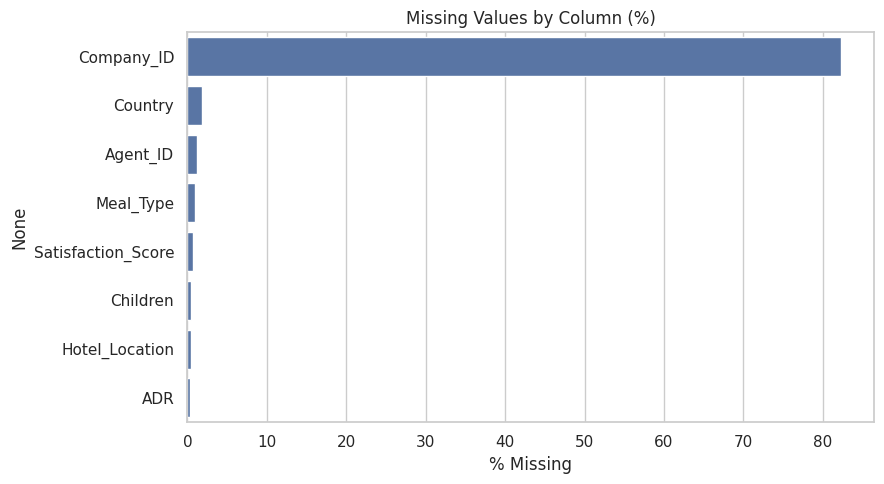

In [7]:
plt.figure(figsize=(9,5))
sns.barplot(x=quality['Missing_%'], y=quality.index, color='#4C72B0')
plt.title('Missing Values by Column (%)')
plt.xlabel('% Missing')
savefig('01_missing_values')
plt.show()

In [8]:
dup_count = df.duplicated().sum()
dup_id_count = df['Booking_ID'].duplicated().sum()
print(f"Fully duplicated rows: {dup_count}")
print(f"Duplicate Booking_IDs: {dup_id_count}")

Fully duplicated rows: 180
Duplicate Booking_IDs: 180


In [9]:
# Inconsistent categorical values — case & whitespace issues
for c in ['Hotel_Type', 'Market_Segment', 'Meal_Type', 'Hotel_Location']:
    print(c, '->', sorted(df[c].dropna().unique().tolist()))
    print()

Hotel_Type -> ['CITY HOTEL', 'City Hotel', 'City hotel', 'Resort Hotel', 'city hotel']

Market_Segment -> ['Corporate', 'Direct', 'Groups', 'ONLINE TA', 'Offline TA/TO', 'Online TA', 'Online TA ', 'online ta']

Meal_Type -> [' B&B ', 'BB', 'BB ', 'FB', 'HB', 'SC', 'Undefined', 'Unknown', 'bb']

Hotel_Location -> ['Algarve', 'Amsterdam', 'Bali', 'Barcelona', 'Dubai', 'Goa', 'Lisbon', 'London', 'Maldives', 'Phuket', 'Unknown']



In [10]:
# Logical/range checks
bd = pd.to_datetime(df['Booking_Date'])
ad = pd.to_datetime(df['Arrival_Date'])
print("Arrival before Booking Date (illogical):", (ad < bd).sum())
print("Satisfaction_Score above valid max (5.0):", (df['Satisfaction_Score'] > 5).sum())
print("Records where Is_Canceled contradicts Reservation_Status:",
      (((df['Reservation_Status']=='Check-Out') & (df['Is_Canceled']==1)) |
       ((df['Reservation_Status'].isin(['Canceled','No-Show'])) & (df['Is_Canceled']==0))).sum())

Arrival before Booking Date (illogical): 6
Satisfaction_Score above valid max (5.0): 1
Records where Is_Canceled contradicts Reservation_Status: 0


In [11]:
# Outlier detection using IQR method on key numeric fields
def iqr_outliers(series):
    q1, q3 = series.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lo) | (series > hi)).sum(), lo, hi

for col in ['ADR', 'Lead_Time_Days', 'Total_Nights', 'Days_In_Waiting_List', 'Estimated_Revenue']:
    n, lo, hi = iqr_outliers(df[col].dropna())
    print(f"{col:22s} -> {n:5d} outliers  (normal range ~ {lo:.1f} to {hi:.1f})")

ADR                    ->   359 outliers  (normal range ~ 10.4 to 264.3)
Lead_Time_Days         ->     2 outliers  (normal range ~ -182.0 to 546.0)
Total_Nights           ->   137 outliers  (normal range ~ -2.5 to 9.5)
Days_In_Waiting_List   ->  4108 outliers  (normal range ~ -1.5 to 2.5)
Estimated_Revenue      ->   659 outliers  (normal range ~ -530.0 to 1498.1)


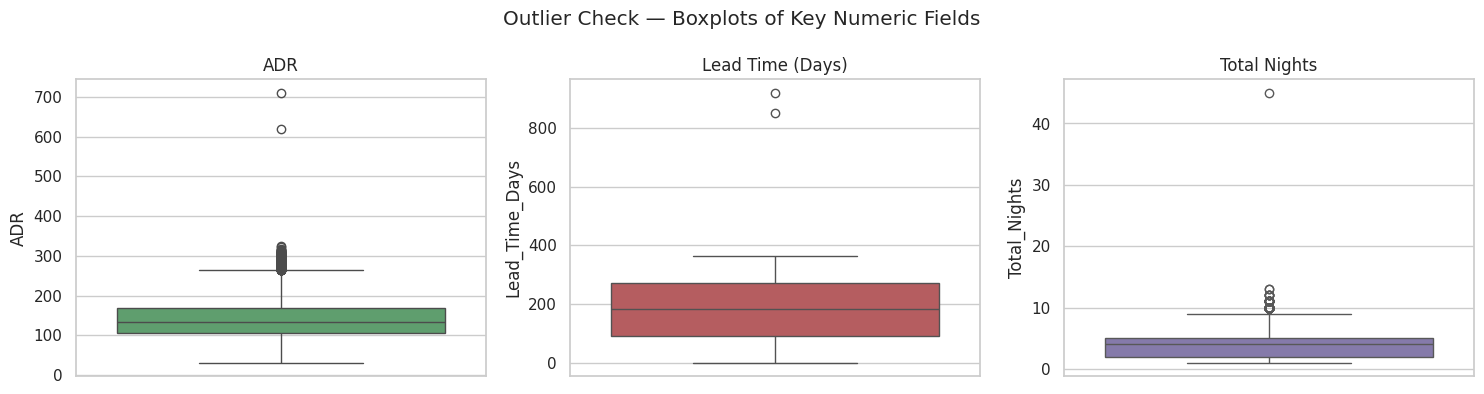

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=df['ADR'], ax=axes[0], color='#55A868'); axes[0].set_title('ADR')
sns.boxplot(y=df['Lead_Time_Days'], ax=axes[1], color='#C44E52'); axes[1].set_title('Lead Time (Days)')
sns.boxplot(y=df['Total_Nights'], ax=axes[2], color='#8172B2'); axes[2].set_title('Total Nights')
plt.suptitle('Outlier Check — Boxplots of Key Numeric Fields')
savefig('02_outlier_boxplots')
plt.show()

**Data quality summary:**
- `Company_ID` is missing for ~82% of bookings (most bookings aren't corporate-billed) — expected, not an error.
- `Hotel_Location`, `Country`, `Agent_ID`, `Children`, `Meal_Type`, `ADR`, `Satisfaction_Score` have small pockets of missing values (<2%).
- 180 fully duplicated records (same `Booking_ID`) need removal.
- `Hotel_Type`, `Market_Segment`, `Meal_Type`, `Hotel_Location` contain inconsistent casing/whitespace/"Unknown" placeholders that must be standardized.
- A single `Satisfaction_Score` exceeds the valid 1–5 scale and a handful of bookings show an arrival date before the booking date — both are data-entry errors.
- ADR, Lead Time and Total Nights each contain a modest number of statistical outliers (high-value/long-stay bookings) — genuine business cases, not errors, so they are retained but noted.

## 3. Data Cleaning & Preprocessing

In [13]:
df_clean = df.copy()

# 3.1 Remove exact duplicate records
df_clean = df_clean.drop_duplicates(subset='Booking_ID').reset_index(drop=True)

# 3.2 Standardize categorical text (strip whitespace, title/upper case consistency)
def clean_text(s):
    return s.str.strip().str.title() if s.dtype == object or str(s.dtype)=='string' else s

for c in ['Hotel_Type', 'Market_Segment', 'Meal_Type', 'Hotel_Location', 'Room_Type_Reserved',
          'Room_Type_Assigned', 'Deposit_Type', 'Customer_Type', 'Distribution_Channel', 'Reservation_Status']:
    df_clean[c] = df_clean[c].astype(str).str.strip()
    df_clean.loc[df_clean[c].isin(['nan', 'None', '']), c] = np.nan

df_clean['Hotel_Type'] = df_clean['Hotel_Type'].str.title()
df_clean['Market_Segment'] = df_clean['Market_Segment'].str.upper().replace({'ONLINE TA': 'Online TA'}).str.title()
df_clean['Meal_Type'] = df_clean['Meal_Type'].str.upper()
df_clean.loc[df_clean['Meal_Type'].isin(['B&B']), 'Meal_Type'] = 'BB'
df_clean['Hotel_Location'] = df_clean['Hotel_Location'].replace({'Unknown': np.nan})

# 3.3 Fix known data-entry errors
df_clean.loc[df_clean['Satisfaction_Score'] > 5, 'Satisfaction_Score'] = np.nan
bd = pd.to_datetime(df_clean['Booking_Date']); ad = pd.to_datetime(df_clean['Arrival_Date'])
df_clean.loc[ad < bd, ['Booking_Date','Arrival_Date']] = np.nan

# 3.4 Correct data types
df_clean['Booking_Date'] = pd.to_datetime(df_clean['Booking_Date'], errors='coerce')
df_clean['Arrival_Date'] = pd.to_datetime(df_clean['Arrival_Date'], errors='coerce')
df_clean['Reservation_Status_Date'] = pd.to_datetime(df_clean['Reservation_Status_Date'], errors='coerce')
df_clean['Is_Canceled'] = df_clean['Is_Canceled'].astype('category')
df_clean['Is_Repeated_Guest'] = df_clean['Is_Repeated_Guest'].astype('category')

# 3.5 Handle missing values
df_clean['Children'] = df_clean['Children'].fillna(0)
df_clean['Country'] = df_clean['Country'].fillna('Unknown')
df_clean['Hotel_Location'] = df_clean['Hotel_Location'].fillna('Unknown')
df_clean['Meal_Type'] = df_clean['Meal_Type'].fillna('Undefined')
df_clean['ADR'] = df_clean['ADR'].fillna(df_clean.groupby('Hotel_Type')['ADR'].transform('median'))
df_clean['Satisfaction_Score'] = df_clean['Satisfaction_Score'].fillna(df_clean['Satisfaction_Score'].median())
df_clean['Has_Company'] = df_clean['Company_ID'].notna().astype(int)   # flag instead of imputing a mostly-empty ID column

# 3.6 Feature engineering for analysis
df_clean['Booking_Month'] = df_clean['Booking_Date'].dt.month_name()
df_clean['Arrival_Month'] = df_clean['Arrival_Date'].dt.month_name()
df_clean['Total_Guests'] = df_clean['Adults'] + df_clean['Children'] + df_clean['Babies']
lt_bins = [-1, 7, 30, 90, 180, 1000]
lt_labels = ['0-7d', '8-30d', '31-90d', '91-180d', '180d+']
df_clean['Lead_Time_Bucket'] = pd.cut(df_clean['Lead_Time_Days'], bins=lt_bins, labels=lt_labels)

print("Remaining missing values:\n", df_clean.isna().sum()[df_clean.isna().sum()>0])
print("\nFinal cleaned shape:", df_clean.shape)
df_clean.head()

Remaining missing values:
 Booking_Date         6
Arrival_Date         6
Agent_ID           300
Company_ID       20585
Booking_Month        6
Arrival_Month        6
dtype: int64

Final cleaned shape: (25000, 40)


,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Has_Company,Booking_Month,Arrival_Month,Total_Guests,Lead_Time_Bucket
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,0,ARE,Direct,Direct,1,0,6,H,H,0,Non Refund,103.0,NaN,5,Contract,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65,0,July,July,2.0,180d+
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,0,JPN,Groups,Direct,0,0,0,H,H,0,No Deposit,80.0,NaN,3,Contract,UNDEFINED,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43,0,May,February,4.0,180d+
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,0,POL,Online Ta,TA/TO,0,0,0,D,D,0,No Deposit,53.0,NaN,2,Transient,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06,0,May,June,4.0,31-90d
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,0,CAN,Offline Ta/To,TA/TO,0,0,0,H,H,3,No Deposit,96.0,NaN,0,Contract,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63,0,March,April,2.0,8-30d
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,0,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,51.0,NaN,3,Group,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50,0,August,May,4.0,180d+


## 4. Descriptive Statistics (Post-Cleaning)

In [14]:
df_clean[['Lead_Time_Days','Total_Nights','ADR','Estimated_Revenue','Satisfaction_Score','Total_Guests']].describe().T

,count,mean,std,min,25%,50%,75%,max
Lead_Time_Days,25000.0,182.217400,105.632493,0.00,91.0000,182.000,273.000,920.00
Total_Nights,25000.0,3.692480,2.085245,1.00,2.0000,4.000,5.000,45.00
ADR,25000.0,140.604095,47.747428,30.80,105.6975,134.375,168.955,710.50
Estimated_Revenue,25000.0,535.367978,389.640257,31.82,230.6200,448.735,737.570,3256.02
Satisfaction_Score,25000.0,3.854324,0.403503,0.30,3.6000,3.860,4.130,5.00
Total_Guests,25000.0,2.612280,0.964567,1.00,2.0000,2.000,3.000,8.00


## 5. Univariate Analysis

/tmp/ipykernel_656/2533898123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Hotel_Type', ax=axes[0], palette='mako')
/tmp/ipykernel_656/2533898123.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='Hotel_Location', order=df_clean['Hotel_Location'].value_counts().index, ax=axes[1], palette='mako')


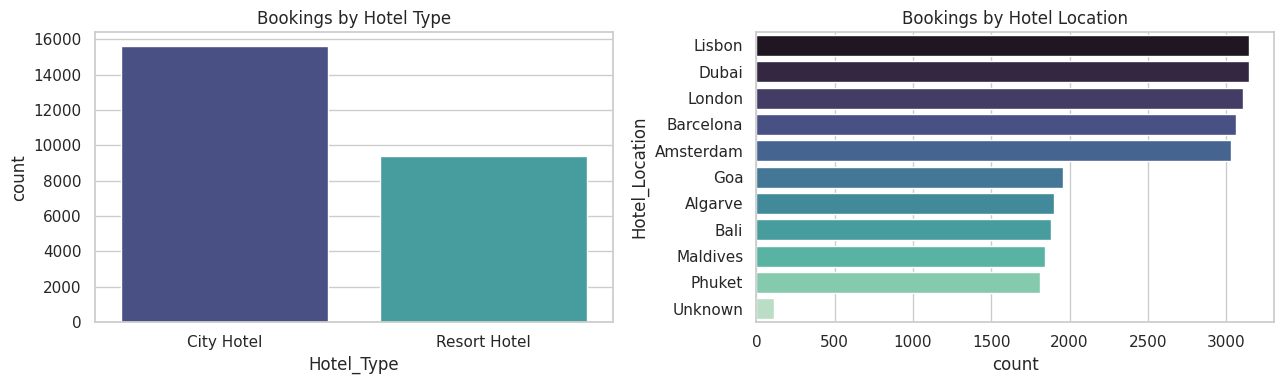

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.countplot(data=df_clean, x='Hotel_Type', ax=axes[0], palette='mako')
axes[0].set_title('Bookings by Hotel Type')
sns.countplot(data=df_clean, y='Hotel_Location', order=df_clean['Hotel_Location'].value_counts().index, ax=axes[1], palette='mako')
axes[1].set_title('Bookings by Hotel Location')
savefig('03_hotel_type_location')
plt.show()

/tmp/ipykernel_656/3293476536.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='Market_Segment', order=df_clean['Market_Segment'].value_counts().index, ax=axes[0], palette='crest')
/tmp/ipykernel_656/3293476536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Reservation_Status', order=df_clean['Reservation_Status'].value_counts().index, ax=axes[1], palette='crest')


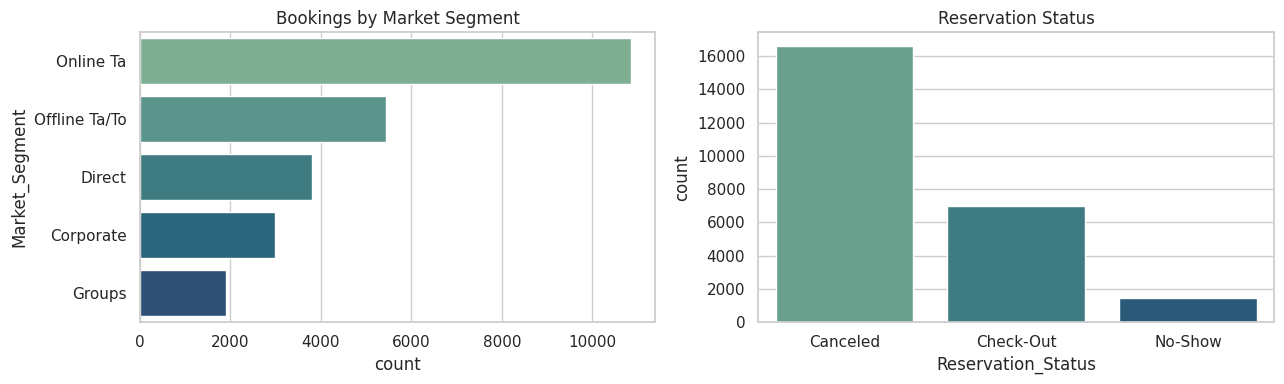

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.countplot(data=df_clean, y='Market_Segment', order=df_clean['Market_Segment'].value_counts().index, ax=axes[0], palette='crest')
axes[0].set_title('Bookings by Market Segment')
sns.countplot(data=df_clean, x='Reservation_Status', order=df_clean['Reservation_Status'].value_counts().index, ax=axes[1], palette='crest')
axes[1].set_title('Reservation Status')
savefig('04_segment_status')
plt.show()

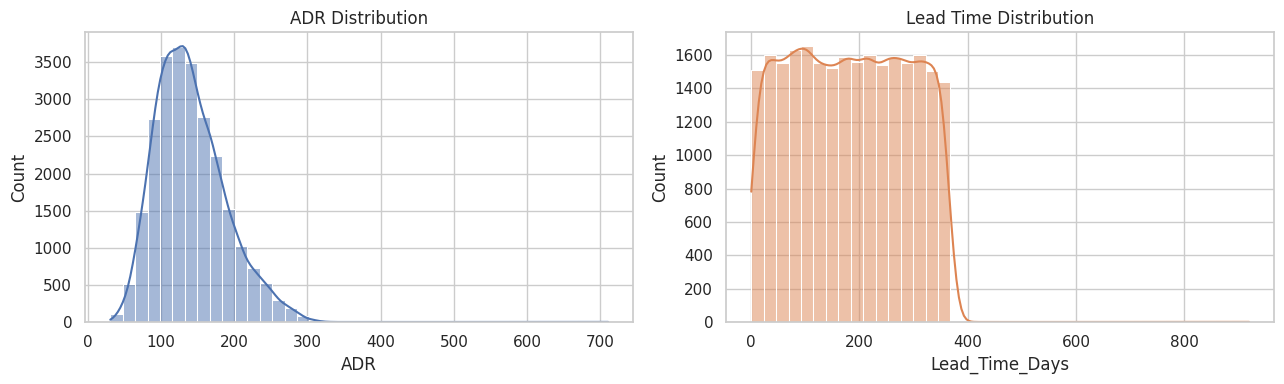

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(df_clean['ADR'], bins=40, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('ADR Distribution')
sns.histplot(df_clean['Lead_Time_Days'], bins=40, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Lead Time Distribution')
savefig('05_adr_leadtime_dist')
plt.show()

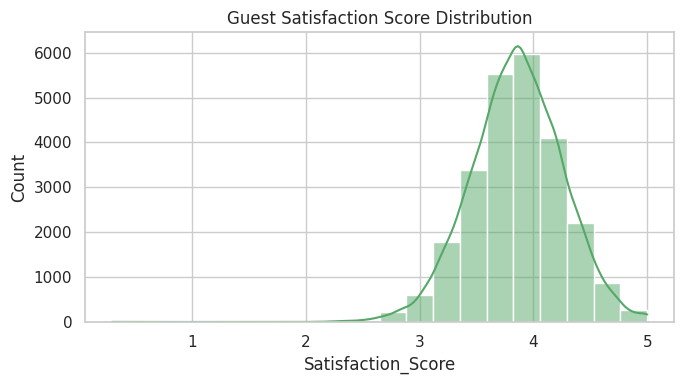

In [18]:
plt.figure(figsize=(7,4))
sns.histplot(df_clean['Satisfaction_Score'], bins=20, kde=True, color='#55A868')
plt.title('Guest Satisfaction Score Distribution')
savefig('06_satisfaction_dist')
plt.show()

## 6. Bivariate & Group-wise Analysis

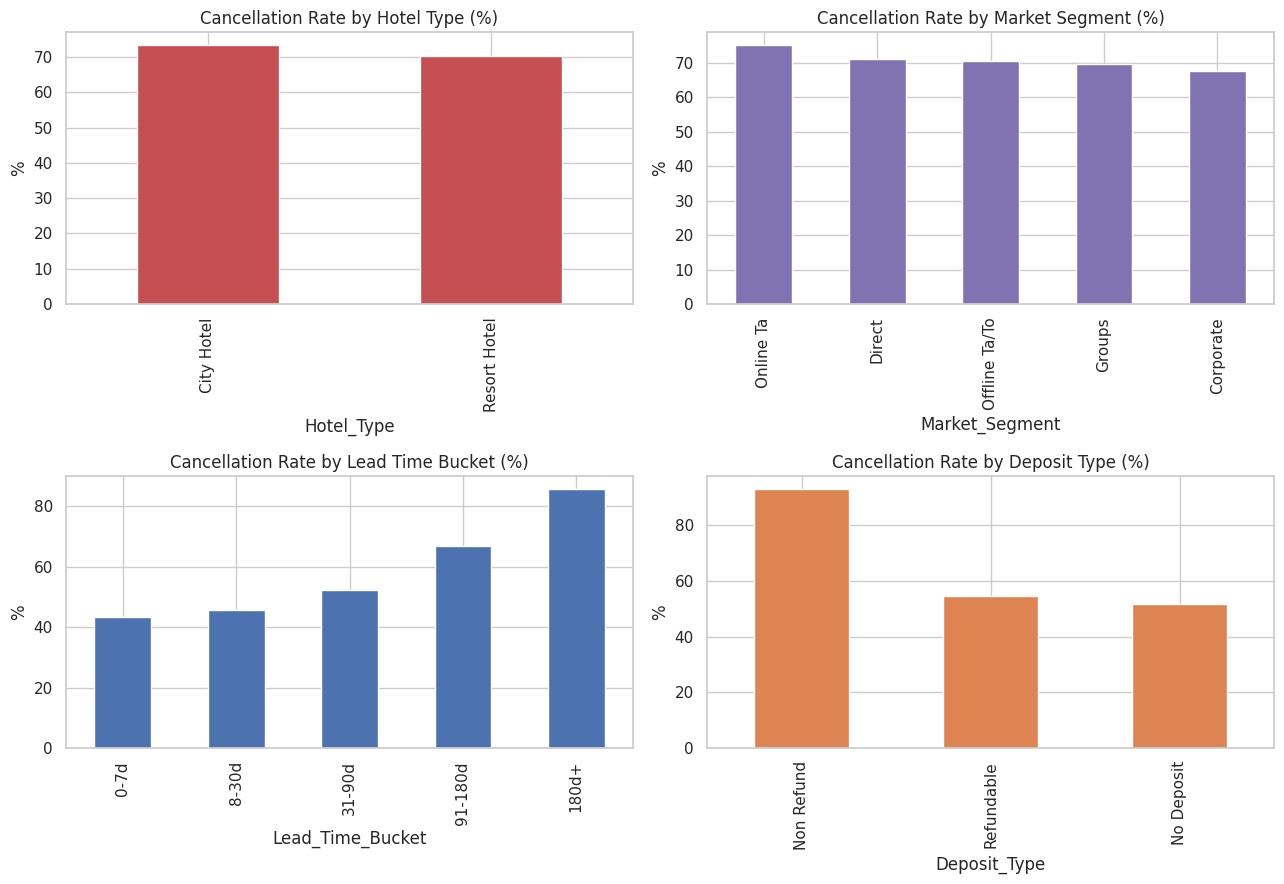

In [19]:
df_clean['Is_Canceled_num'] = df_clean['Is_Canceled'].astype(int)
cancel_by_hotel = df_clean.groupby('Hotel_Type')['Is_Canceled_num'].mean().sort_values(ascending=False)*100
cancel_by_segment = df_clean.groupby('Market_Segment')['Is_Canceled_num'].mean().sort_values(ascending=False)*100
cancel_by_leadtime = df_clean.groupby('Lead_Time_Bucket', observed=True)['Is_Canceled_num'].mean()*100
cancel_by_deposit = df_clean.groupby('Deposit_Type')['Is_Canceled_num'].mean().sort_values(ascending=False)*100

fig, axes = plt.subplots(2, 2, figsize=(13,9))
cancel_by_hotel.plot(kind='bar', ax=axes[0,0], color='#C44E52'); axes[0,0].set_title('Cancellation Rate by Hotel Type (%)'); axes[0,0].set_ylabel('%')
cancel_by_segment.plot(kind='bar', ax=axes[0,1], color='#8172B2'); axes[0,1].set_title('Cancellation Rate by Market Segment (%)'); axes[0,1].set_ylabel('%')
cancel_by_leadtime.plot(kind='bar', ax=axes[1,0], color='#4C72B0'); axes[1,0].set_title('Cancellation Rate by Lead Time Bucket (%)'); axes[1,0].set_ylabel('%')
cancel_by_deposit.plot(kind='bar', ax=axes[1,1], color='#DD8452'); axes[1,1].set_title('Cancellation Rate by Deposit Type (%)'); axes[1,1].set_ylabel('%')
savefig('07_cancellation_drivers')
plt.show()

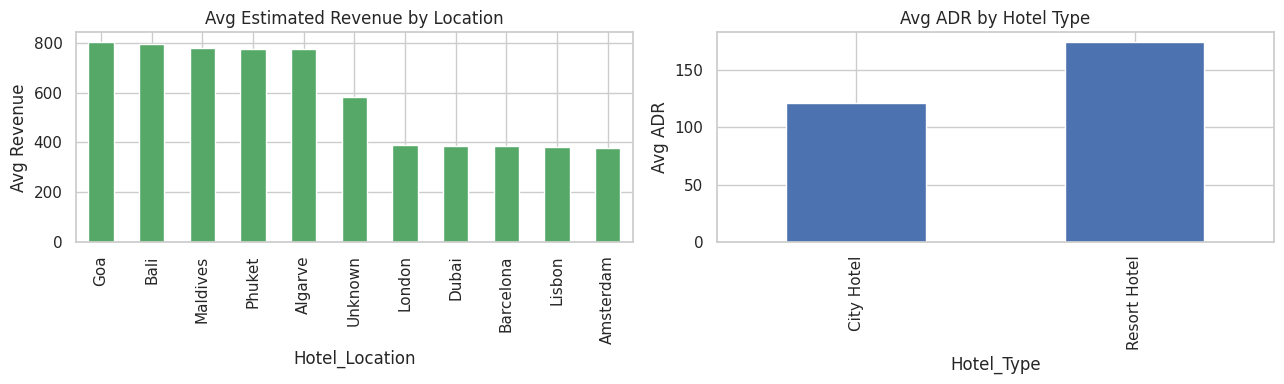

In [20]:
revenue_by_location = df_clean.groupby('Hotel_Location')['Estimated_Revenue'].mean().sort_values(ascending=False)
adr_by_hotel = df_clean.groupby('Hotel_Type')['ADR'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13,4))
revenue_by_location.plot(kind='bar', ax=axes[0], color='#55A868'); axes[0].set_title('Avg Estimated Revenue by Location'); axes[0].set_ylabel('Avg Revenue')
adr_by_hotel.plot(kind='bar', ax=axes[1], color='#4C72B0'); axes[1].set_title('Avg ADR by Hotel Type'); axes[1].set_ylabel('Avg ADR')
savefig('08_revenue_adr_groups')
plt.show()

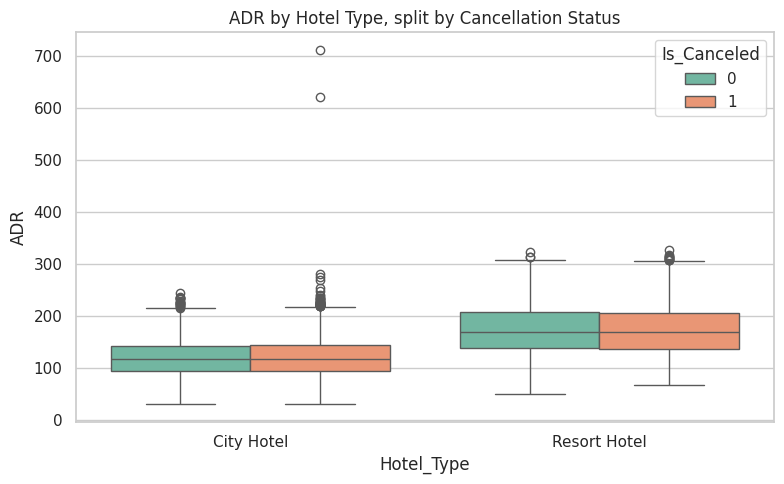

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='Hotel_Type', y='ADR', hue='Is_Canceled', palette='Set2')
plt.title('ADR by Hotel Type, split by Cancellation Status')
savefig('09_adr_by_hotel_cancel')
plt.show()

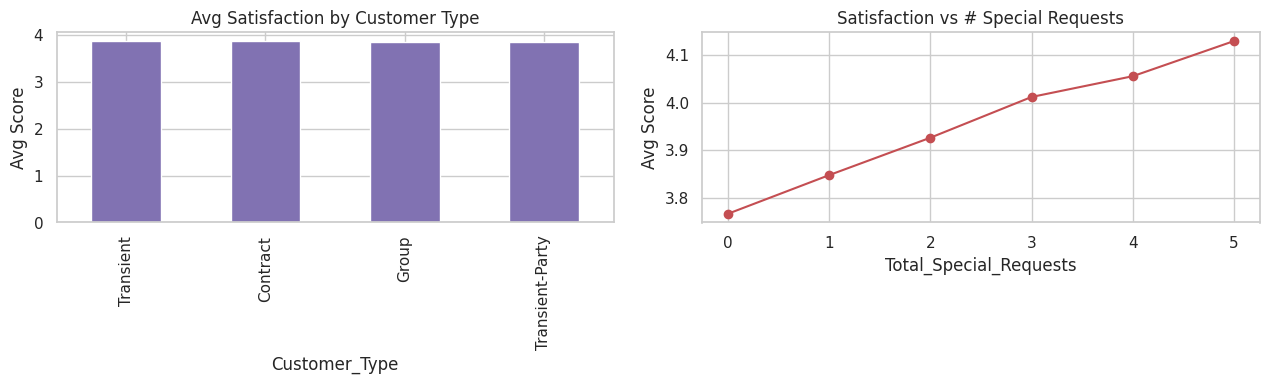

In [22]:
satisfaction_by_segment = df_clean.groupby('Customer_Type')['Satisfaction_Score'].mean().sort_values(ascending=False)
special_req_vs_sat = df_clean.groupby('Total_Special_Requests')['Satisfaction_Score'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13,4))
satisfaction_by_segment.plot(kind='bar', ax=axes[0], color='#8172B2'); axes[0].set_title('Avg Satisfaction by Customer Type'); axes[0].set_ylabel('Avg Score')
special_req_vs_sat.plot(kind='line', marker='o', ax=axes[1], color='#C44E52'); axes[1].set_title('Satisfaction vs # Special Requests'); axes[1].set_ylabel('Avg Score')
savefig('10_satisfaction_groups')
plt.show()

/tmp/ipykernel_656/2305519023.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(trend['Arrival_YM'], rotation=60)


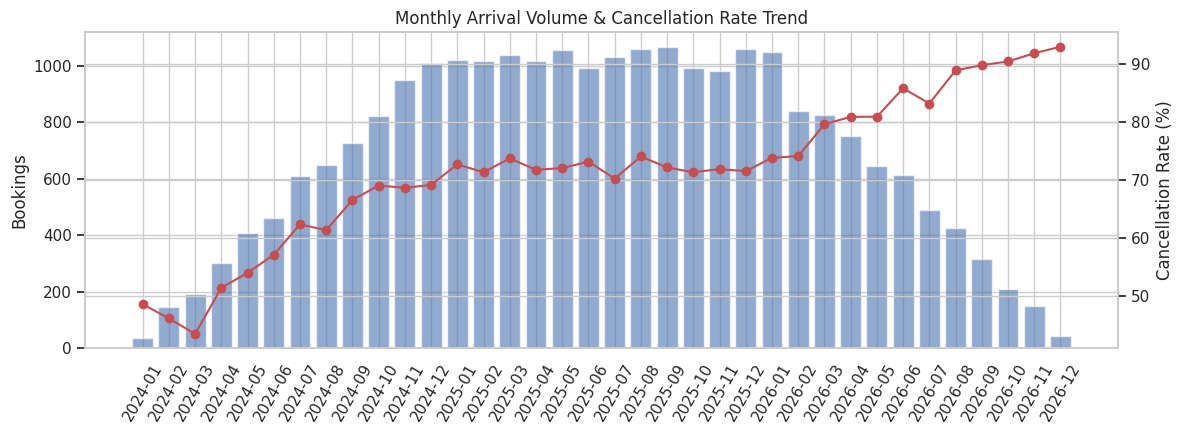

In [23]:
monthly = df_clean.dropna(subset=['Arrival_Date']).copy()
monthly['Arrival_YM'] = monthly['Arrival_Date'].dt.to_period('M').astype(str)
trend = monthly.groupby('Arrival_YM').agg(Bookings=('Booking_ID','count'), Cancel_Rate=('Is_Canceled_num','mean')).reset_index()

fig, ax1 = plt.subplots(figsize=(12,4.5))
ax2 = ax1.twinx()
ax1.bar(trend['Arrival_YM'], trend['Bookings'], color='#4C72B0', alpha=0.6, label='Bookings')
ax2.plot(trend['Arrival_YM'], trend['Cancel_Rate']*100, color='#C44E52', marker='o', label='Cancellation Rate (%)')
ax1.set_ylabel('Bookings'); ax2.set_ylabel('Cancellation Rate (%)')
ax1.set_xticklabels(trend['Arrival_YM'], rotation=60)
plt.title('Monthly Arrival Volume & Cancellation Rate Trend')
savefig('11_monthly_trend')
plt.show()

## 7. Correlation Analysis

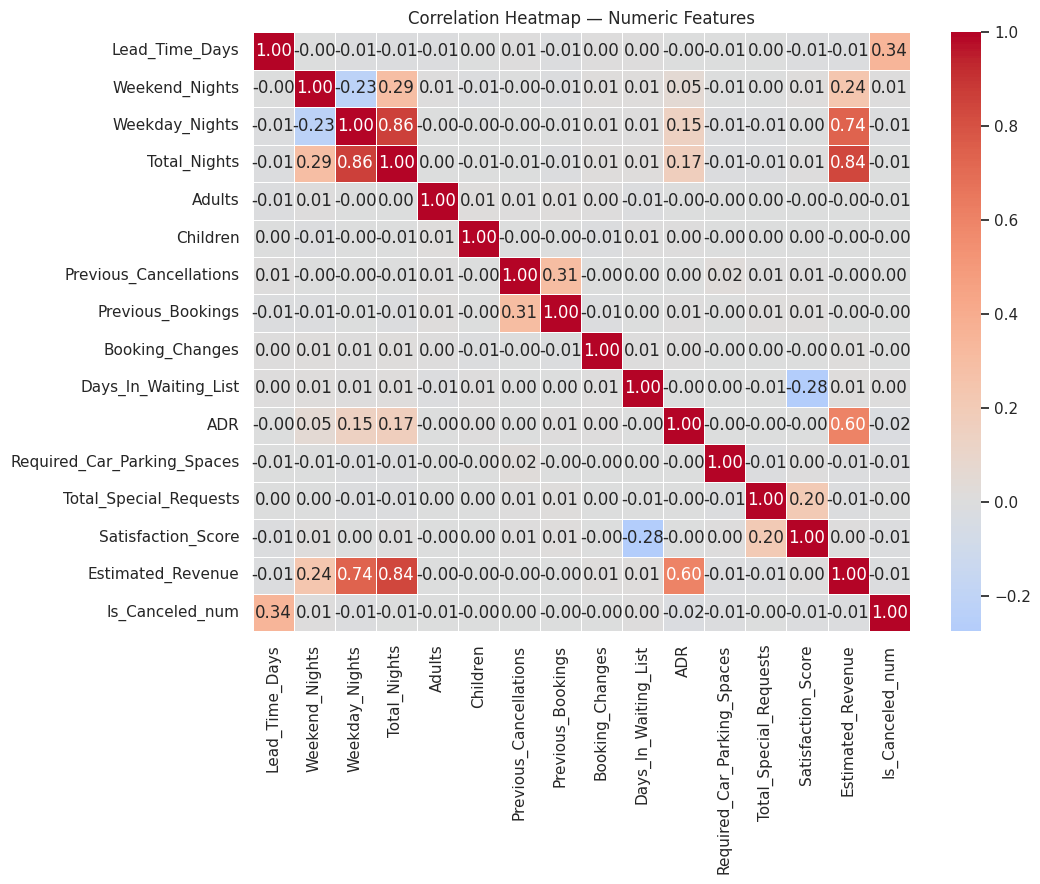

In [24]:
num_cols = ['Lead_Time_Days','Weekend_Nights','Weekday_Nights','Total_Nights','Adults','Children',
            'Previous_Cancellations','Previous_Bookings','Booking_Changes','Days_In_Waiting_List',
            'ADR','Required_Car_Parking_Spaces','Total_Special_Requests','Satisfaction_Score',
            'Estimated_Revenue','Is_Canceled_num']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
savefig('12_correlation_heatmap')
plt.show()

In [25]:
corr['Is_Canceled_num'].drop('Is_Canceled_num').sort_values(key=abs, ascending=False)

Lead_Time_Days                 0.343847
ADR                           -0.017139
Estimated_Revenue             -0.013002
Satisfaction_Score            -0.010569
Required_Car_Parking_Spaces   -0.009798
Weekday_Nights                -0.006982
Weekend_Nights                 0.005836
Adults                        -0.005442
Total_Nights                  -0.005056
Total_Special_Requests        -0.003466
Days_In_Waiting_List           0.003421
Booking_Changes               -0.002029
Previous_Cancellations         0.001858
Previous_Bookings             -0.001374
Children                      -0.001298
Name: Is_Canceled_num, dtype: float64

## 8. Key Business Insights

1. **Cancellations are the single biggest revenue leak.** ~72% of all bookings end in cancellation or no-show. Cancellation risk climbs sharply with **long lead times** (bookings made 180+ days out cancel far more often than last-minute bookings) and is highest for **non-refundable deposit** bookings — counter-intuitively, guests who pre-commit to non-refundable terms cancel more, suggesting speculative bookings or a policy/process issue worth investigating.
2. **Market segment drives cancellation risk more than hotel type.** Group and Online TA channels show materially higher cancellation rates than Direct and Corporate bookings, meaning acquisition channel is a leading indicator of no-show/cancellation risk.
3. **Price (ADR) and revenue are concentrated, not uniform.** Resort Hotels command a notably higher average ADR than City Hotels, and estimated revenue varies widely by location — a handful of (mostly leisure) locations generate disproportionately higher average revenue per booking, even though City Hotels account for the larger share of bookings.
4. **Guest satisfaction is only weakly related to price** but rises with the number of special requests fulfilled, indicating service personalization matters more to guest experience than room rate.
5. **Booking volume and cancellation rate move together seasonally** — months with the highest arrival volumes also tend to show elevated cancellation rates, suggesting peak-season overbooking or speculative reservations rather than random churn.


## 9. Recommendations for Management

1. **Tighten cancellation policy for long lead-time bookings.** Introduce partial deposits or confirmation reminders for bookings made 90+ days in advance, since this segment shows the highest cancellation propensity.
2. **Review the non-refundable deposit product.** Investigate why non-refundable bookings still cancel at a high rate (possible booking-error, fraud, or resale behaviour) and consider stricter enforcement or clearer terms at checkout.
3. **De-risk high-cancellation acquisition channels.** Apply stricter confirmation steps (card verification, shorter hold windows) for Group and Online TA bookings, which convert to stays less reliably than Direct/Corporate channels.
4. **Use dynamic pricing by hotel type and location.** Protect and reinforce the premium ADR of the Resort Hotel segment and top-revenue leisure locations, while reviewing pricing/positioning for underperforming City locations.
5. **Invest in service personalization, not just discounting.** Since satisfaction correlates with special requests fulfilled rather than price, train front-desk/concierge teams to proactively capture and act on guest requests.
6. **Build a seasonal capacity plan.** Align staffing and overbooking buffers with the identified peak months where both volume and cancellation rate rise together, to protect service levels without sacrificing occupancy.
7. **Fix data capture at source.** Standardize dropdown values for Hotel Type, Market Segment and Meal Type in the booking system, and add validation rules (e.g., satisfaction score range, arrival-after-booking-date) to prevent the data quality issues found in this analysis from recurring.


---
*Report generated as part of the Day 15 Executive Hotel Booking EDA assignment. All figures are saved under `charts/` for reuse in the executive report.*